# Breast Cancer Wisconsin (Diagnostic) — Exploratory Data Analysis

This notebook performs a structured, reproducible, and clinically motivated EDA of the Breast Cancer Wisconsin (Diagnostic) dataset.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)
sns.set_style("whitegrid")

output_dir = Path("../Results/eda_figures")
output_dir.mkdir(parents=True, exist_ok=True)

## Dataset Overview

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df["diagnosis"] = df["target"].map({0: "Malignant", 1: "Benign"})

n_samples, n_columns = df.shape
n_features = n_columns - 2  # exclude target and diagnosis
n_classes = df["diagnosis"].nunique()

print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features}")
print(f"Number of classes: {n_classes}")
print("\nClass labels:", sorted(df["diagnosis"].unique()))

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

df.head()

Dataset shape: (569, 32)
Number of samples: 569
Number of features: 30
Number of classes: 2

Class labels: ['Benign', 'Malignant']

Column names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target', 'diagnosis']

Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


The dataset contains 569 breast mass samples with 30 computed real-valued features describing cell nucleus morphology, plus target labels. The task is binary classification (benign vs malignant), making this dataset suitable for studying discriminative morphologic patterns and feature redundancy before modeling.

## Data Cleaning & Missingness

In [3]:
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values in dataset: {missing_values.sum()}")

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
diagnosis                  0
dtype: int64

Total missing values in dataset: 0


No missing values are present, so no imputation is required. This reduces preprocessing complexity and supports reproducible downstream modeling without data-repair assumptions.

## Class Distribution

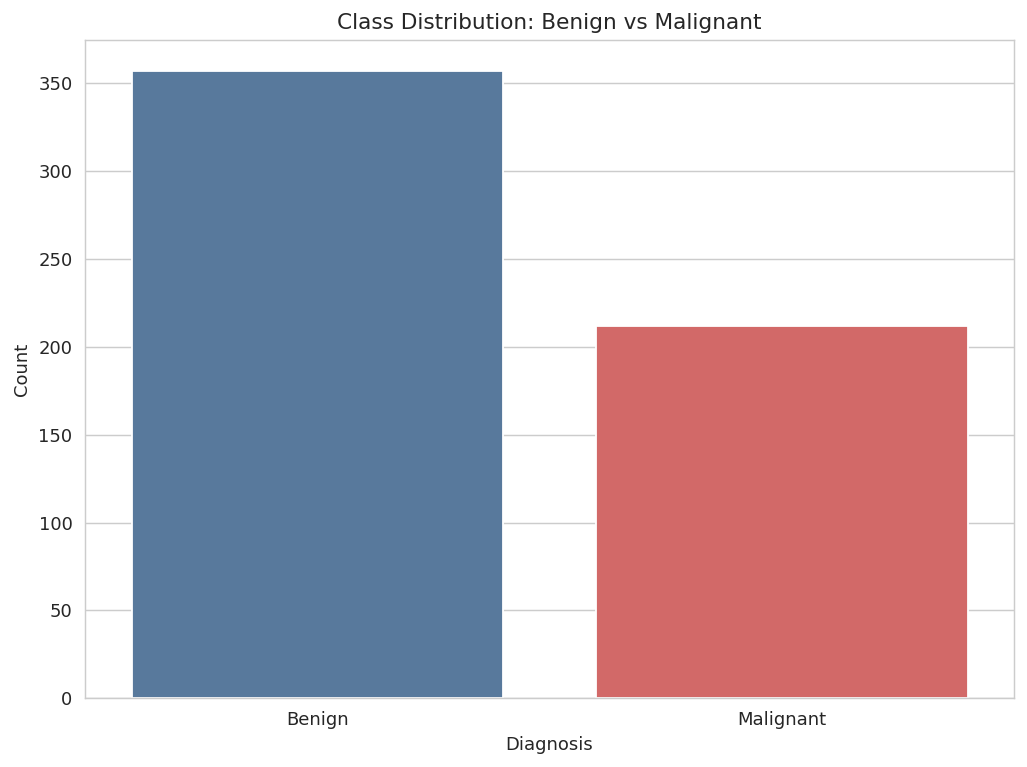

diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(8, 6), dpi=130)
ax = sns.countplot(data=df, x="diagnosis", hue="diagnosis", order=["Benign", "Malignant"], palette={"Benign": "#4C78A8", "Malignant": "#E45756"}, legend=False)
ax.set_title("Class Distribution: Benign vs Malignant")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(output_dir / "class_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

print(df["diagnosis"].value_counts())

The dataset is moderately imbalanced (more benign than malignant cases). For modeling, this motivates stratified splitting and potentially class-sensitive metrics (e.g., recall, ROC-AUC, PR-AUC), since missed malignant cases are clinically costly.

## Summary Statistics by Class

In [6]:
class_means = df.groupby("diagnosis").mean(numeric_only=True)
display(class_means)

feature_means_only = class_means.drop(columns=["target"], errors="ignore")
mean_diff = (feature_means_only.loc["Malignant"] - feature_means_only.loc["Benign"]).abs().sort_values(ascending=False)

print("Top 10 absolute mean differences between classes:")
display(mean_diff.head(10).to_frame(name="absolute_mean_difference"))

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
diagnosis,,,,,,,,,,,,,,,,,,,,,
Benign,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442,1.0
Malignant,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530,0.0


Top 10 absolute mean differences between classes:


,absolute_mean_difference
worst area,863.386881
mean area,515.586219
worst perimeter,54.364392
area error,51.537257
mean perimeter,37.289971
worst radius,7.755010
worst texture,5.803138
mean radius,5.316306
mean texture,3.690144
perimeter error,2.323608


Features such as area, perimeter, radius, concavity, and compactness typically show the largest class-wise shifts. These reflect larger and more irregular nuclear architecture in malignant tumors, indicating strong biological plausibility for discrimination.

## Feature Distributions

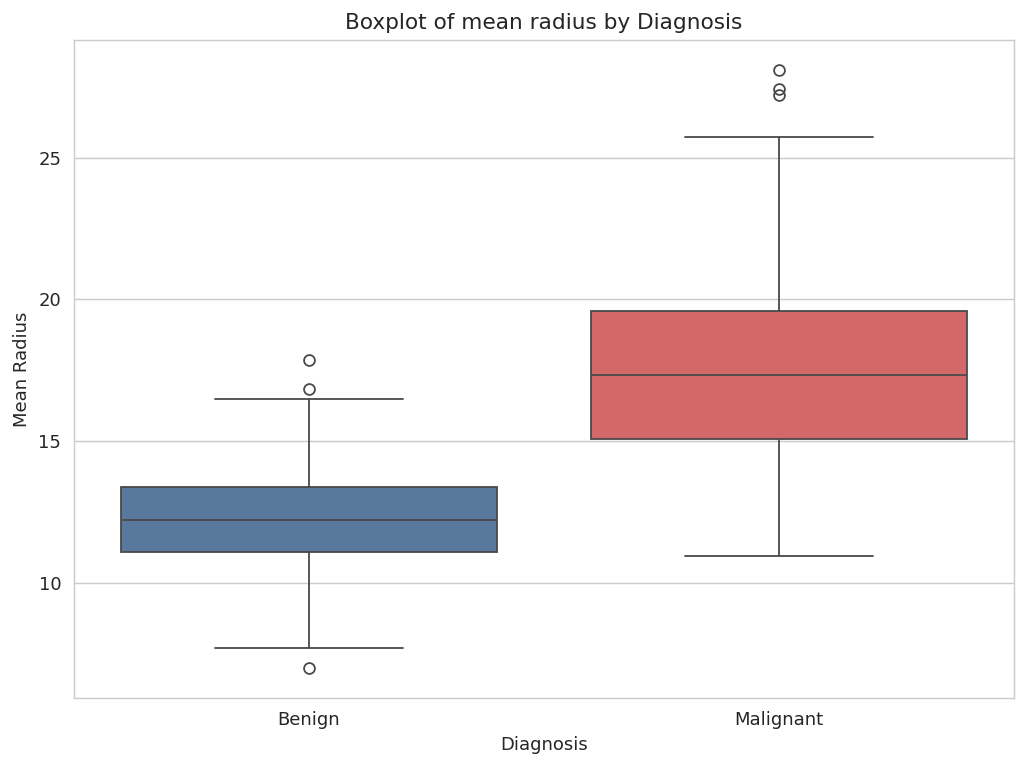

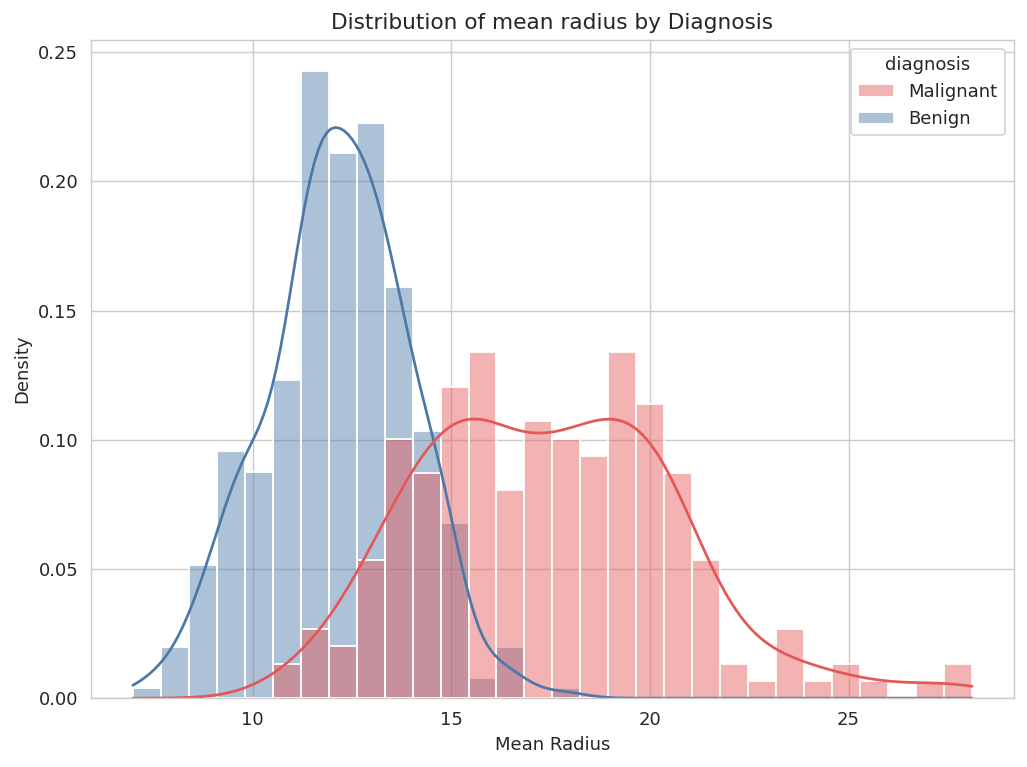

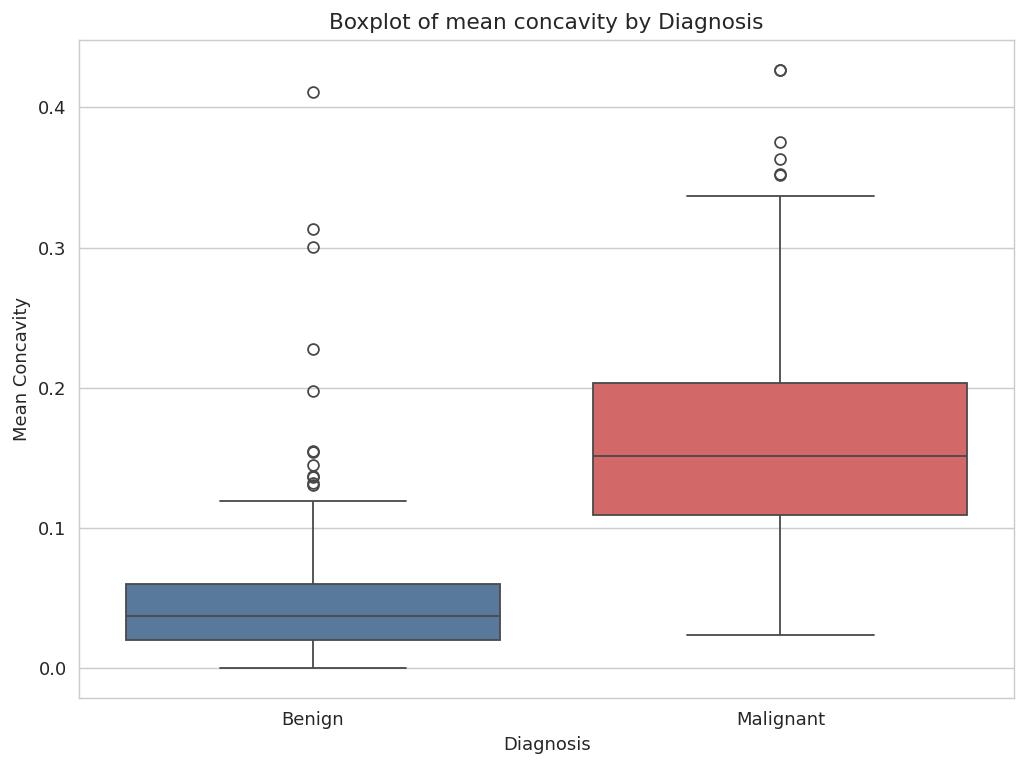

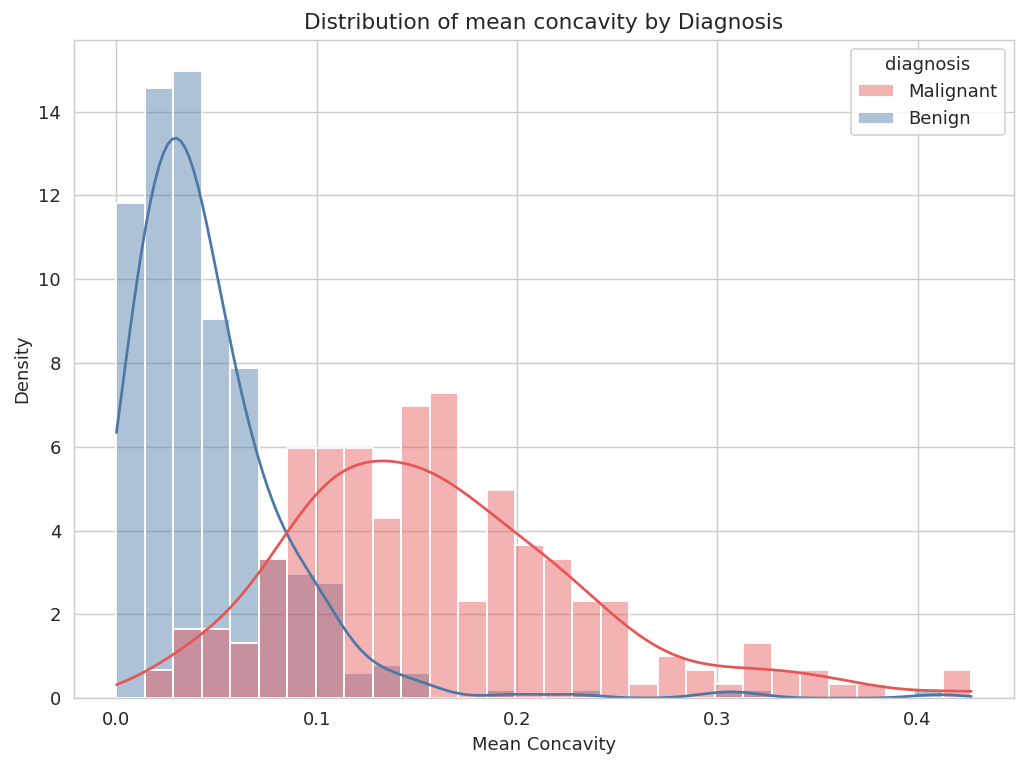

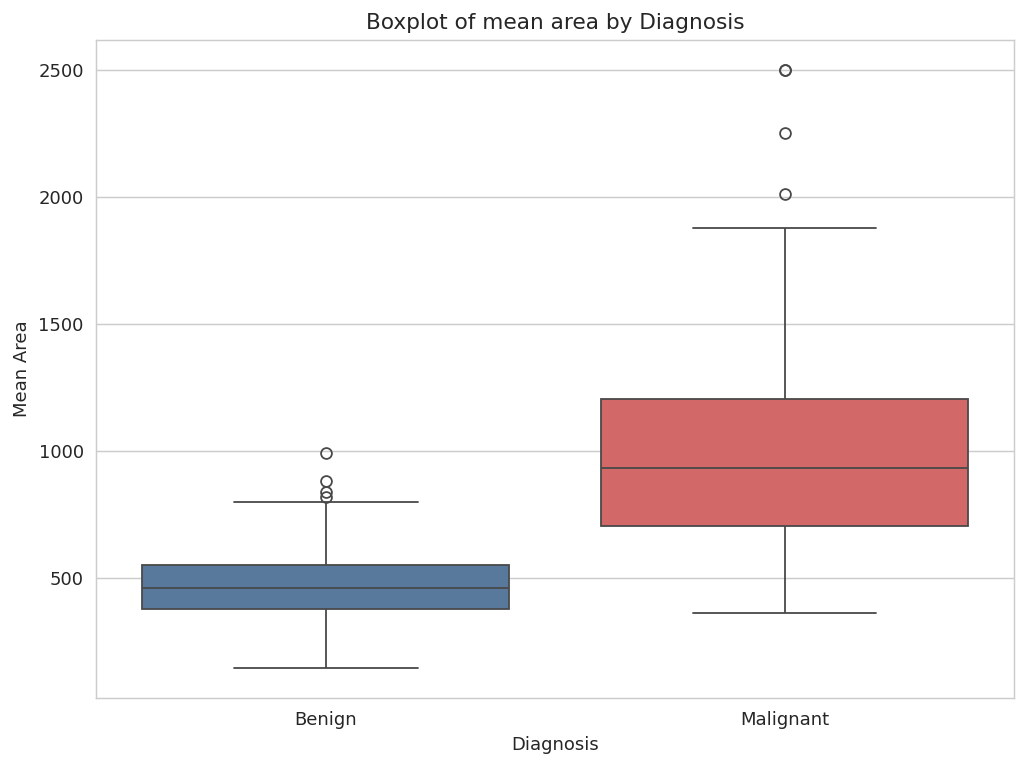

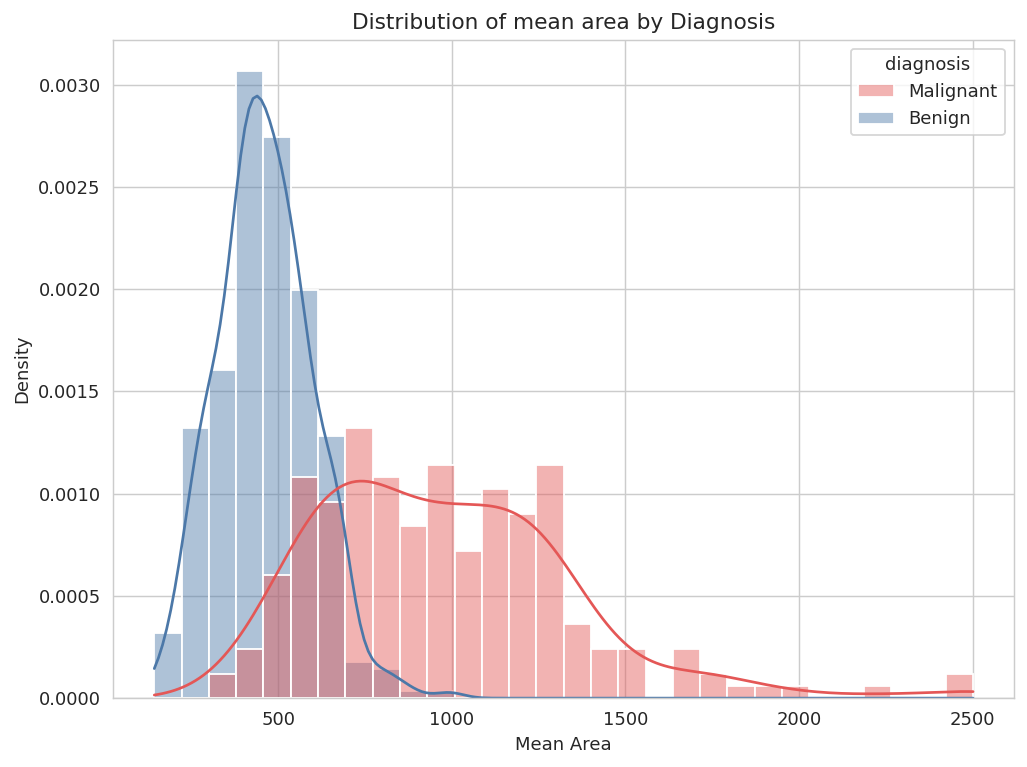

In [7]:
feature_palette = {"Benign": "#4C78A8", "Malignant": "#E45756"}
high_impact_features = ["mean radius", "mean concavity", "mean area"]

for feature in high_impact_features:
    fig, ax = plt.subplots(figsize=(8, 6), dpi=130)
    sns.boxplot(data=df, x="diagnosis", y=feature, hue="diagnosis", order=["Benign", "Malignant"], palette=feature_palette, dodge=False, ax=ax)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_title(f"Boxplot of {feature} by Diagnosis")
    ax.set_xlabel("Diagnosis")
    ax.set_ylabel(feature.title())
    plt.tight_layout()
    plt.savefig(output_dir / f"boxplot_{feature.replace(' ', '_')}.png", dpi=130, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6), dpi=130)
    sns.histplot(data=df, x=feature, hue="diagnosis", kde=True, stat="density", common_norm=False, bins=30, palette=feature_palette, alpha=0.45, ax=ax)
    ax.set_title(f"Distribution of {feature} by Diagnosis")
    ax.set_xlabel(feature.title())
    ax.set_ylabel("Density")
    plt.tight_layout()
    plt.savefig(output_dir / f"hist_kde_{feature.replace(' ', '_')}.png", dpi=130, bbox_inches="tight")
    plt.show()

For mean radius, mean concavity, and mean area, malignant distributions shift upward with clearer upper tails and higher medians. Clinically, these patterns are consistent with larger, more complex, and less smooth nuclear structures in malignant tissue.

## Correlation Analysis

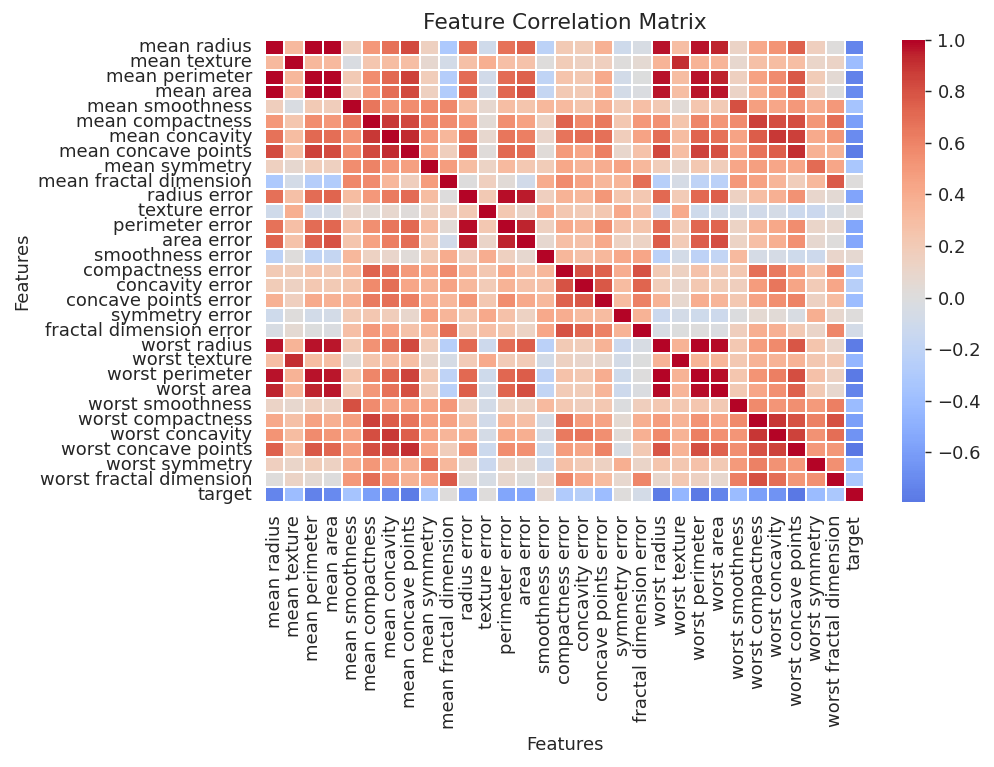

Highly correlated feature pairs (|r| >= 0.85):


,feature_1,feature_2,correlation
2,mean radius,mean perimeter,0.997855
642,worst radius,worst perimeter,0.993708
3,mean radius,mean area,0.987357
65,mean perimeter,mean area,0.986507
643,worst radius,worst area,0.984015
705,worst perimeter,worst area,0.977578
322,radius error,perimeter error,0.972794
84,mean perimeter,worst perimeter,0.970387
20,mean radius,worst radius,0.969539
82,mean perimeter,worst radius,0.969476


In [8]:
corr_matrix = df.drop(columns=["diagnosis"]).corr(numeric_only=True)

plt.figure(figsize=(8, 6), dpi=130)
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Feature Correlation Matrix")
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig(output_dir / "correlation_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
    .query("abs(correlation) >= 0.85")
    .sort_values(by="correlation", key=lambda s: s.abs(), ascending=False)
)

print("Highly correlated feature pairs (|r| >= 0.85):")
display(high_corr_pairs.head(15))

Strong correlation clusters appear among radius, perimeter, and area (including their worst and error variants), indicating substantial multicollinearity. This suggests redundant geometric descriptors that can be reduced via feature selection, regularization, or dimensionality reduction with minimal predictive loss.

## Feature Relationships with Target

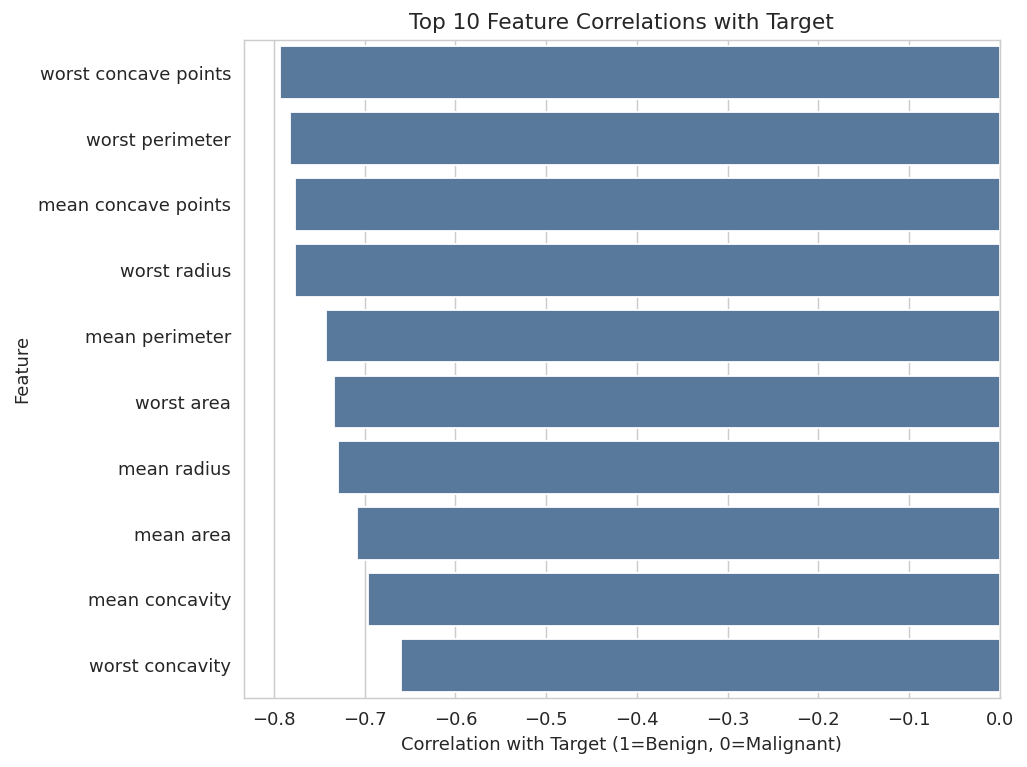

worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
worst area             -0.733825
mean radius            -0.730029
mean area              -0.708984
mean concavity         -0.696360
worst concavity        -0.659610
Name: target, dtype: float64

In [9]:
target_corr = df.drop(columns=["diagnosis"]).corr(numeric_only=True)["target"].drop("target")
top_target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).head(10).index)

plt.figure(figsize=(8, 6), dpi=130)
sns.barplot(x=top_target_corr.values, y=top_target_corr.index, color="#4C78A8")
plt.title("Top 10 Feature Correlations with Target")
plt.xlabel("Correlation with Target (1=Benign, 0=Malignant)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(output_dir / "target_relationships.png", dpi=130, bbox_inches="tight")
plt.show()

top_target_corr

Features related to size and boundary irregularity exhibit the strongest relationships with diagnosis. Their high absolute correlation with target reinforces that malignant lesions tend to be larger and more structurally irregular than benign lesions.

## Dimensionality Reduction (Optional but Recommended)

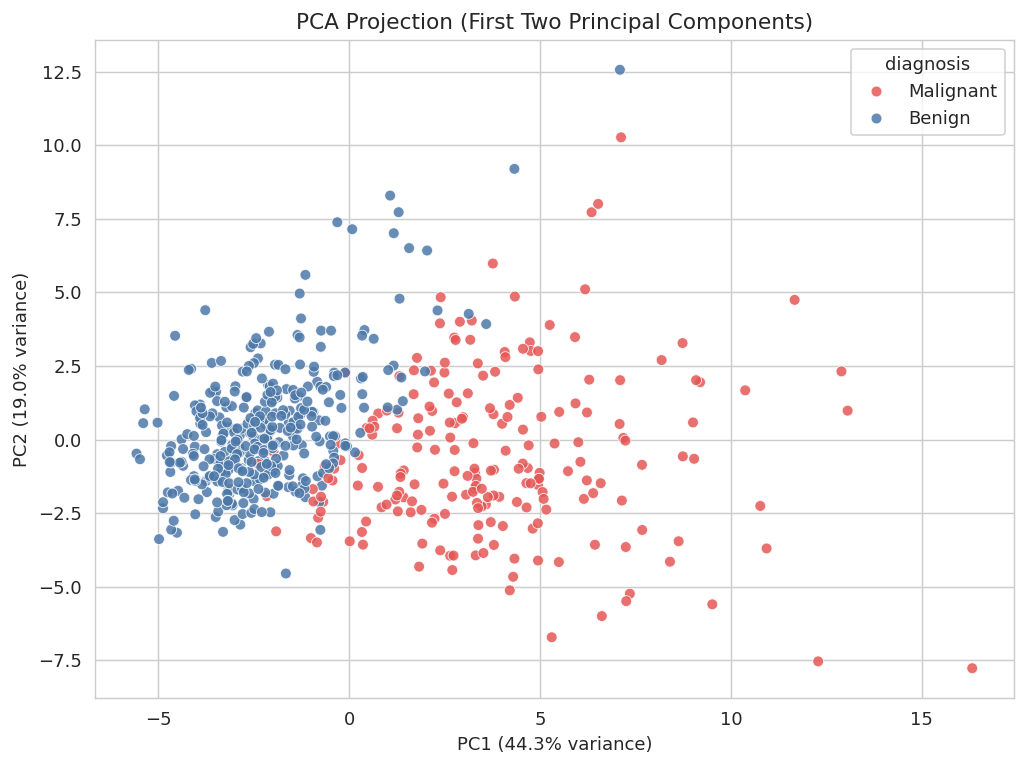

Explained variance by first two PCs: 0.632


In [10]:
X = df.drop(columns=["target", "diagnosis"])
y = df["diagnosis"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["diagnosis"] = y.values

plt.figure(figsize=(8, 6), dpi=130)
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="diagnosis", palette=feature_palette, alpha=0.85)
plt.title("PCA Projection (First Two Principal Components)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.tight_layout()
plt.savefig(output_dir / "pca_scatter.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Explained variance by first two PCs: {pca.explained_variance_ratio_.sum():.3f}")

The PCA scatter plot typically shows meaningful class separability in low-dimensional space, suggesting that the underlying signal is strong. This supports the expectation that multiple classification models can perform well, even with reduced feature representations.

## Key Exploratory Insights

- No missing values were detected, enabling straightforward preprocessing.
- Nuclear morphology features show strong class separation, especially size and boundary-complexity descriptors.
- Malignant tumors tend to be larger and more irregular than benign tumors across multiple feature families.
- Radius, perimeter, and area features are highly correlated, indicating geometric redundancy and multicollinearity.
- Reduced feature sets (feature selection or PCA-informed compression) are likely to preserve strong predictive performance while simplifying models.